In [1]:
!pip install pandas openpyxl seaborn matplotlib

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
# Load the dataset
df = pd.read_csv('online_retail_II.csv')

# Check the shape
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (1067371, 8)

First 5 rows:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [5]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

print(f"\nData types:")
print(df.dtypes)

print(f"\nDate range of data:")
print(f"From: {df['InvoiceDate'].min()}")
print(f"To: {df['InvoiceDate'].max()}")

Missing values per column:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Data types:
Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object

Date range of data:
From: 2009-12-01 07:45:00
To: 2011-12-09 12:50:00


In [6]:
# Remove rows with missing Customer ID
df_clean = df.dropna(subset=['Customer ID'])

# Convert InvoiceDate to datetime
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# Remove cancelled orders (Invoice starting with 'C')
df_clean = df_clean[~df_clean['Invoice'].astype(str).str.startswith('C')]

# Remove negative quantities and zero prices
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[df_clean['Price'] > 0]

# Convert Customer ID to integer
df_clean['Customer ID'] = df_clean['Customer ID'].astype(int)

print(f"Original rows: {len(df):,}")
print(f"Clean rows: {len(df_clean):,}")
print(f"Rows removed: {len(df) - len(df_clean):,}")
print(f"\nDate range after cleaning:")
print(f"From: {df_clean['InvoiceDate'].min()}")
print(f"To: {df_clean['InvoiceDate'].max()}")

Original rows: 1,067,371
Clean rows: 805,549
Rows removed: 261,822

Date range after cleaning:
From: 2009-12-01 07:45:00
To: 2011-12-09 12:50:00


In [7]:
# Extract the invoice month (period)
df_clean['InvoiceMonth'] = df_clean['InvoiceDate'].dt.to_period('M')

# Get each customer's FIRST purchase month = their cohort
df_clean['CohortMonth'] = df_clean.groupby('Customer ID')['InvoiceDate'].transform('min').dt.to_period('M')

# Calculate cohort index (how many months since first purchase)
def get_cohort_index(row):
    return (row['InvoiceMonth'].year - row['CohortMonth'].year) * 12 + \
           (row['InvoiceMonth'].month - row['CohortMonth'].month)

df_clean['CohortIndex'] = df_clean.apply(get_cohort_index, axis=1)

print("Cohort columns created successfully!")
print(f"\nSample of cohort data:")
df_clean[['Customer ID', 'InvoiceDate', 'InvoiceMonth', 'CohortMonth', 'CohortIndex']].head(10)

Cohort columns created successfully!

Sample of cohort data:


,Customer ID,InvoiceDate,InvoiceMonth,CohortMonth,CohortIndex
0,13085,2009-12-01 07:45:00,2009-12,2009-12,0
1,13085,2009-12-01 07:45:00,2009-12,2009-12,0
2,13085,2009-12-01 07:45:00,2009-12,2009-12,0
3,13085,2009-12-01 07:45:00,2009-12,2009-12,0
4,13085,2009-12-01 07:45:00,2009-12,2009-12,0
5,13085,2009-12-01 07:45:00,2009-12,2009-12,0
6,13085,2009-12-01 07:45:00,2009-12,2009-12,0
7,13085,2009-12-01 07:45:00,2009-12,2009-12,0
8,13085,2009-12-01 07:46:00,2009-12,2009-12,0
9,13085,2009-12-01 07:46:00,2009-12,2009-12,0


In [8]:
# Count unique customers per cohort per month
cohort_data = df_clean.groupby(['CohortMonth', 'CohortIndex'])['Customer ID'].nunique().reset_index()

# Pivot into matrix format
cohort_matrix = cohort_data.pivot_table(
    index='CohortMonth',
    columns='CohortIndex',
    values='Customer ID'
)

# Calculate retention rates (divide each column by Month 0)
cohort_sizes = cohort_matrix.iloc[:, 0]
retention_matrix = cohort_matrix.divide(cohort_sizes, axis=0).round(3) * 100

print("Cohort retention matrix (% of original cohort returning):")
retention_matrix.iloc[:, :7]

Cohort retention matrix (% of original cohort returning):


CohortIndex,0,1,2,3,4,5,6
CohortMonth,,,,,,,
2009-12,100.0,35.3,33.4,42.5,38.0,35.9,37.7
2010-01,100.0,20.6,31.1,30.5,26.4,30.0,25.8
2010-02,100.0,23.8,22.5,29.1,24.6,20.1,19.3
2010-03,100.0,19.0,23.0,24.2,23.3,20.3,24.6
2010-04,100.0,19.4,19.4,16.3,18.4,22.4,27.6
2010-05,100.0,15.7,16.9,17.3,17.7,25.6,21.3
2010-06,100.0,17.4,18.9,20.4,23.0,28.5,12.6
2010-07,100.0,15.6,18.3,29.6,29.0,14.0,11.3
2010-08,100.0,20.4,29.6,32.1,17.3,11.7,9.9


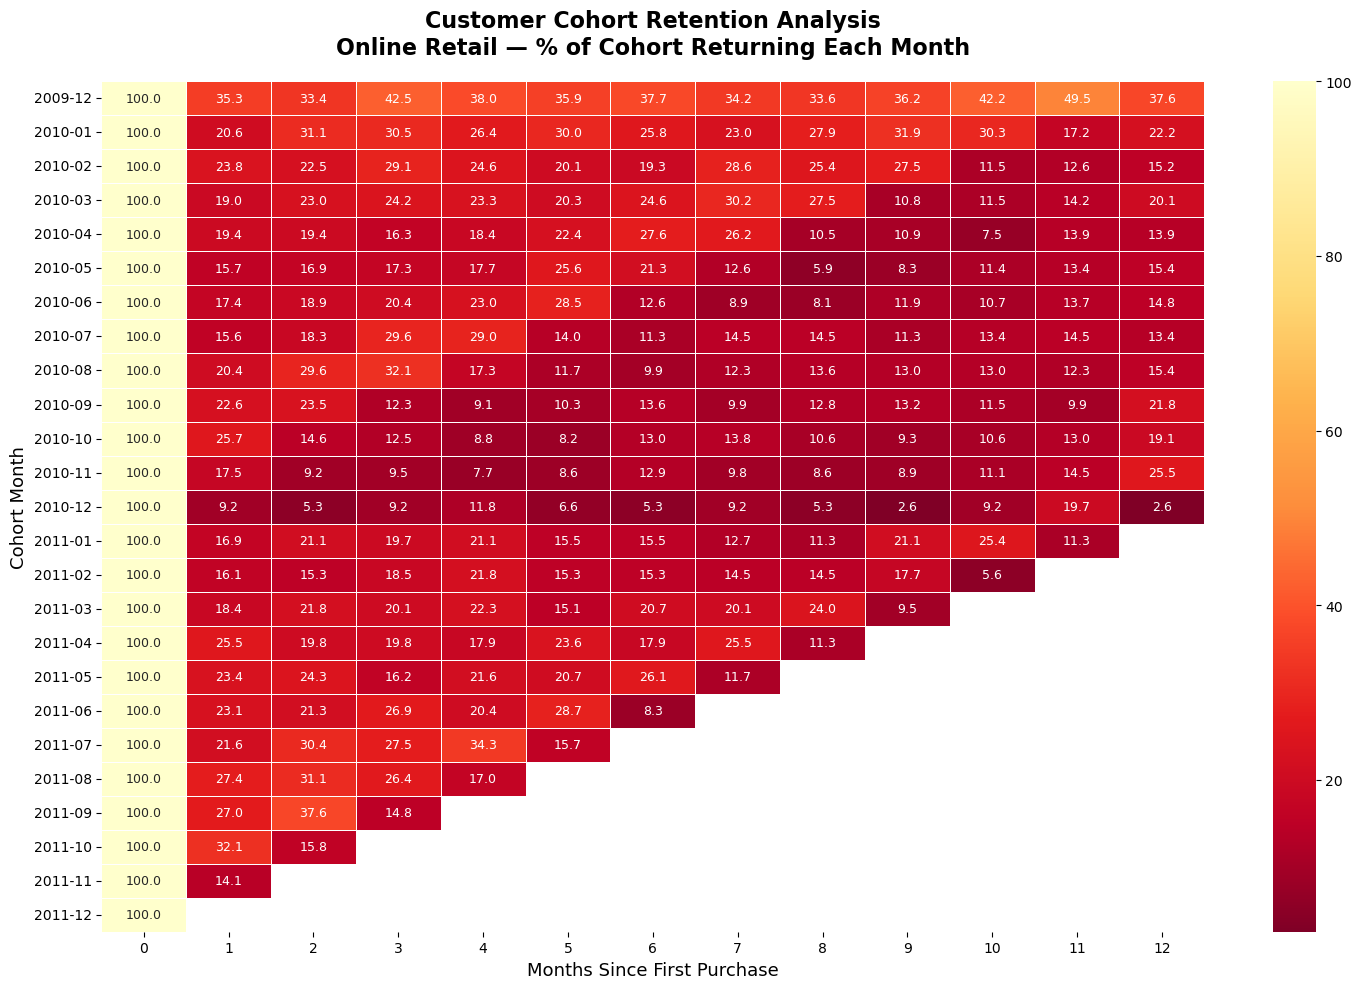

Heatmap saved!


In [9]:
plt.figure(figsize=(15, 10))

sns.heatmap(
    retention_matrix.iloc[:, :13],
    annot=True,
    fmt='.1f',
    cmap='YlOrRd_r',
    linewidths=0.5,
    annot_kws={"size": 9}
)

plt.title('Customer Cohort Retention Analysis\nOnline Retail — % of Cohort Returning Each Month',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Months Since First Purchase', fontsize=13)
plt.ylabel('Cohort Month', fontsize=13)
plt.tight_layout()
plt.savefig('cohort_retention_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Heatmap saved!")

In [10]:
# Average Month 1 retention across all cohorts
avg_m1 = retention_matrix[1].mean()
avg_m3 = retention_matrix[3].mean()
avg_m6 = retention_matrix[6].mean()

# Best and worst cohorts
best_cohort = retention_matrix[1].idxmax()
worst_cohort = retention_matrix[1].idxmin()

print("=" * 50)
print("KEY RETENTION INSIGHTS")
print("=" * 50)
print(f"\nAverage Month 1 Retention:  {avg_m1:.1f}%")
print(f"Average Month 3 Retention:  {avg_m3:.1f}%")
print(f"Average Month 6 Retention:  {avg_m6:.1f}%")
print(f"\nBest performing cohort:  {best_cohort}")
print(f"Worst performing cohort: {worst_cohort}")
print(f"\nDec 2009 cohort Month 1 retention: {retention_matrix.loc['2009-12', 1]:.1f}%")
print(f"Dec 2009 cohort Month 6 retention: {retention_matrix.loc['2009-12', 6]:.1f}%")

KEY RETENTION INSIGHTS

Average Month 1 Retention:  21.2%
Average Month 3 Retention:  21.6%
Average Month 6 Retention:  17.8%

Best performing cohort:  2009-12
Worst performing cohort: 2010-12

Dec 2009 cohort Month 1 retention: 35.3%
Dec 2009 cohort Month 6 retention: 37.7%


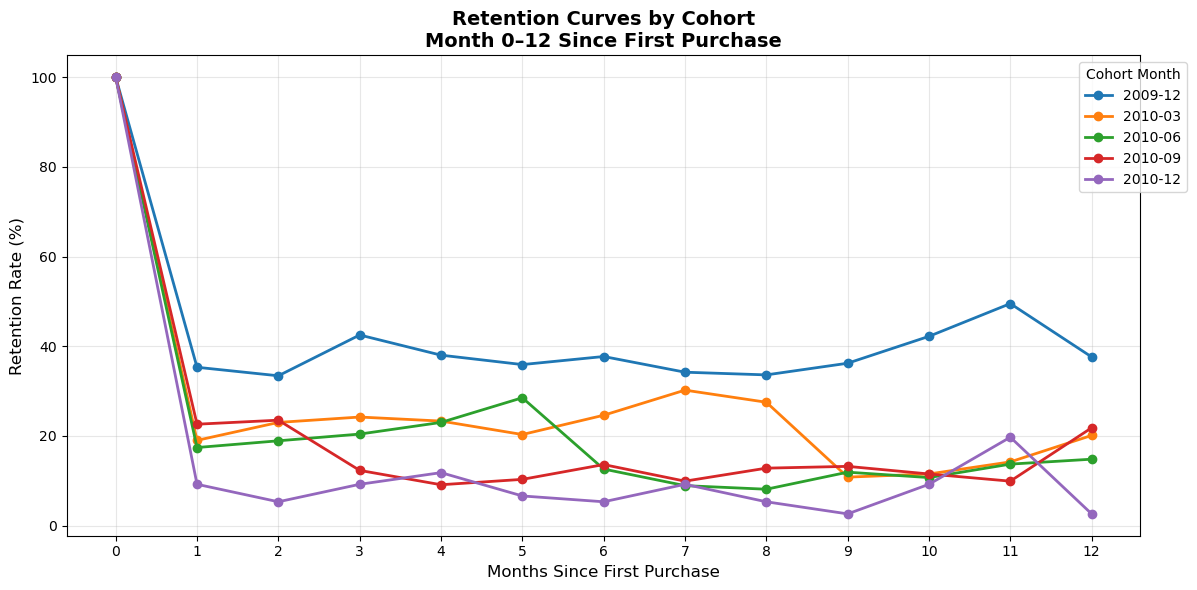

Retention curves saved!


In [11]:
# Plot retention curves for select cohorts
fig, ax = plt.subplots(figsize=(12, 6))

cohorts_to_plot = ['2009-12', '2010-03', '2010-06', '2010-09', '2010-12']

for cohort in cohorts_to_plot:
    if cohort in retention_matrix.index.astype(str):
        data = retention_matrix.loc[cohort, :].iloc[:13]
        ax.plot(data.index, data.values, marker='o', linewidth=2, label=cohort)

ax.set_title('Retention Curves by Cohort\nMonth 0–12 Since First Purchase',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Months Since First Purchase', fontsize=12)
ax.set_ylabel('Retention Rate (%)', fontsize=12)
ax.legend(title='Cohort Month', bbox_to_anchor=(1.05, 1))
ax.grid(True, alpha=0.3)
ax.set_xticks(range(13))
plt.tight_layout()
plt.savefig('retention_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("Retention curves saved!")

In [12]:
insights = """
COHORT RETENTION ANALYSIS — KEY FINDINGS
==========================================

DATASET: Online Retail II (UCI)
- 1,067,371 total transactions
- 805,549 after cleaning (removed guest checkouts & cancellations)
- Period: December 2009 – December 2011
- Geography: Primarily United Kingdom

KEY METRICS:
- Average Month 1 Retention: 21.2%
- Average Month 3 Retention: 21.6%
- Average Month 6 Retention: 17.8%

FINDING 1 — Early Drop-off is the Core Problem:
79% of customers do not return after their first purchase.
The steepest drop happens between Month 0 and Month 1.
This suggests the biggest opportunity is in post-purchase
engagement — email campaigns, loyalty programs, 
personalised recommendations within the first 30 days.

FINDING 2 — Dec 2009 Cohort is an Outlier:
Month 1 retention: 35.3% vs 21.2% average
Month 6 retention: 37.7% — actually higher than Month 1
This cohort likely represents the store's early loyal 
customer base. Understanding what made this cohort 
different (acquisition channel, product mix, promotions)
could unlock a repeatable retention strategy.

FINDING 3 — Survivors Become Loyal:
Customers who return past Month 3 show relatively 
stable retention (17-22% range). This means the product
has genuine loyalty potential — the challenge is 
surviving the first 90 days.

RECOMMENDATIONS:
1. Build a 30-day onboarding email sequence for new customers
2. Investigate Dec 2009 acquisition source — replicate it
3. Create a loyalty programme targeting Month 2-3 customers
   to push them past the critical retention threshold
4. Segment holiday shoppers (Oct-Dec cohorts) separately
   as they show systematically lower retention

"""

print(insights)

# Save to text file
with open('key_insights.txt', 'w') as f:
    f.write(insights)
    
print("Insights saved to key_insights.txt")


COHORT RETENTION ANALYSIS — KEY FINDINGS

DATASET: Online Retail II (UCI)
- 1,067,371 total transactions
- 805,549 after cleaning (removed guest checkouts & cancellations)
- Period: December 2009 – December 2011
- Geography: Primarily United Kingdom

KEY METRICS:
- Average Month 1 Retention: 21.2%
- Average Month 3 Retention: 21.6%
- Average Month 6 Retention: 17.8%

FINDING 1 — Early Drop-off is the Core Problem:
79% of customers do not return after their first purchase.
The steepest drop happens between Month 0 and Month 1.
This suggests the biggest opportunity is in post-purchase
engagement — email campaigns, loyalty programs, 
personalised recommendations within the first 30 days.

FINDING 2 — Dec 2009 Cohort is an Outlier:
Month 1 retention: 35.3% vs 21.2% average
Month 6 retention: 37.7% — actually higher than Month 1
This cohort likely represents the store's early loyal 
customer base. Understanding what made this cohort 
different (acquisition channel, product mix, promotions)

In [13]:
# Save the retention matrix to CSV
retention_matrix.to_csv('retention_matrix.csv')

# Save cohort sizes
cohort_sizes.to_csv('cohort_sizes.csv')

print("Files saved successfully!")
print("\nFiles in your project folder:")
import os
for file in os.listdir('.'):
    print(f"  - {file}")

Files saved successfully!

Files in your project folder:
  - .ipynb_checkpoints
  - cohort_retention_analysis.ipynb
  - cohort_retention_heatmap.png
  - cohort_sizes.csv
  - key_insights.txt
  - online_retail_II.csv
  - retention_curves.png
  - retention_matrix.csv


In [15]:
readme = """# Project 1: Customer Cohort Retention Analysis

## Overview
Cohort retention analysis on 1 million+ real e-commerce transactions 
to identify customer retention patterns and actionable insights.

## Dataset
- **Source:** Online Retail II UCI (Kaggle)
- **Size:** 1,067,371 transactions -> 805,549 after cleaning
- **Period:** December 2009 - December 2011
- **Region:** Primarily United Kingdom

## Tools Used
- Python (Pandas, Matplotlib, Seaborn)
- Jupyter Notebook

## Key Findings
- Average Month 1 retention: **21.2%** - 4 in 5 customers don't return
- Dec 2009 cohort significantly outperforms - **35.3%** Month 1 retention
- Customers surviving past Month 3 show stable loyalty (17-22% range)
- Biggest opportunity: post-purchase engagement in first 30 days

## Recommendations
1. Build 30-day onboarding email sequence for new customers
2. Investigate Dec 2009 acquisition source and replicate
3. Create loyalty programme targeting Month 2-3 customers
4. Segment holiday shoppers separately - systematically lower retention

## Visualizations
### Retention Heatmap
![Cohort Retention Heatmap](cohort_retention_heatmap.png)

### Retention Curves
![Retention Curves](retention_curves.png)
"""

with open('README.md', 'w', encoding='utf-8') as f:
    f.write(readme)

print("README.md created successfully!")

README.md created successfully!
